In [14]:
import pandas as pd

composite_data = pd.read_parquet('../data/composite_data.parquet')

In [15]:
# Let's examine what's actually in our dataset
print("Dataset columns:")
print(composite_data.columns.tolist())
print(f"\nDataset shape: {composite_data.shape}")
print(f"\nSample of sentiment columns:")
print(composite_data[['custom_sentiment', 'finbert_sentiment']].describe())

Dataset columns:
['ticker', 'custom_sentiment', 'finbert_sentiment', 'date', 'on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date', 'p-7', 'p-6', 'p-5', 'p-4', 'p-3', 'p-2', 'p-1', 'p+0', 'p+1', 'p+2', 'p+3', 'p+4', 'p+5', 'p+6', 'p+7']

Dataset shape: (39124, 23)

Sample of sentiment columns:
       custom_sentiment  finbert_sentiment
count      39124.000000       39124.000000
mean           0.123784          -0.016409
std            1.129345           1.003936
min           -5.614654          -4.198019
25%           -0.462225          -0.263871
50%           -0.032856           0.386785
75%            0.825882           0.641648
max            5.978311           0.901393


In [16]:
# Calculate returns for 1, 3, and 7 day horizons
composite_data['r1'] = (composite_data['p+1'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r3'] = (composite_data['p+3'] - composite_data['p+0']) / composite_data['p+0']
composite_data['r7'] = (composite_data['p+7'] - composite_data['p+0']) / composite_data['p+0']

In [17]:
# Prepare datasets
r1_data = composite_data.dropna(subset=['r1']).sort_values('date').reset_index(drop=True)
r3_data = composite_data.dropna(subset=['r3']).sort_values('date').reset_index(drop=True)
r7_data = composite_data.dropna(subset=['r7']).sort_values('date').reset_index(drop=True)

In [18]:
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

input_features = ['custom_sentiment', 'finbert_sentiment']

best_rmse = np.inf
best_model = None
best_config = None
perfs = []

for df, target in [(r1_data, 'r1'), (r3_data, 'r3'), (r7_data, 'r7')]:
  for ignore_settings in [[], ['on_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date']]:
    for to_ignore in ignore_settings:
      df = df[df[to_ignore] == False].reset_index(drop=True)
    if len(df) < 500:
      continue
    df = df.sort_values('date')
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx]
    val = df.iloc[split_idx:]
    X_train = train[input_features]
    X_val = val[input_features]
    Y_train = train[target]
    Y_val = val[target]
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, Y_train)
    pred_ridge = ridge.predict(X_val)
    rmse_ridge = root_mean_squared_error(Y_val, pred_ridge)
    perfs.append(("Ridge", ignore_settings, target, rmse_ridge))

    if rmse_ridge < best_rmse:
      best_rmse = rmse_ridge
      best_model = ridge
      best_config = ("Ridge", ignore_settings, target)

    xgb = XGBRegressor(
      n_estimators=200,
      max_depth=3,
      learning_rate=0.05,
      subsample=0.8,
      objective='reg:squarederror',
      tree_method='hist'
    )
    xgb.fit(X_train, Y_train)
    pred_xgb = xgb.predict(X_val)
    rmse_xgb = root_mean_squared_error(Y_val, pred_xgb)
    perfs.append(("XGBoost", ignore_settings, target, rmse_xgb))

    if rmse_xgb < best_rmse:
      best_rmse = rmse_xgb
      best_model = xgb
      best_config = ("XGBoost", ignore_settings, target)

In [19]:
print(perfs)
print(best_rmse)
print(best_config)

[('Ridge', [], 'r1', 0.1243315444296504), ('XGBoost', [], 'r1', 0.12660338720450173), ('Ridge', ['on_volatile_date'], 'r1', 0.12208237770037944), ('XGBoost', ['on_volatile_date'], 'r1', 0.12346616890408744), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'r1', 0.12301574610558023), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date'], 'r1', 0.12386065733143817), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'r1', 0.12839562206530386), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'r1', 0.12891206914483214), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date'], 'r1', 0.1537405518086763), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date'], 'r1', 0.1554012361964043), ('Ridge', [], 'r3', 0.19986158300241813), ('XGBoost', [], 'r3', 0.19912824004963842), ('Ridge', ['on_volatile_date'], 'r

In [20]:
df = r1_data.copy()
df = df[df['on_volatile_date'] == False].reset_index(drop=True)
df = df[df['adjacent_volatile_date'] == False].reset_index(drop=True)

df = df.sort_values('date').reset_index(drop=True)

print(len(df))

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:]

X_test = test_df[input_features]
Y_test = test_df['r1']

36705


In [21]:
y_pred = best_model.predict(X_test)

sign_match = np.sign(y_pred) == np.sign(Y_test)
sign_accuracy = sign_match.mean()

print(f"Sign accuracy for best model: {sign_accuracy:.3f}")

Sign accuracy for best model: 0.489


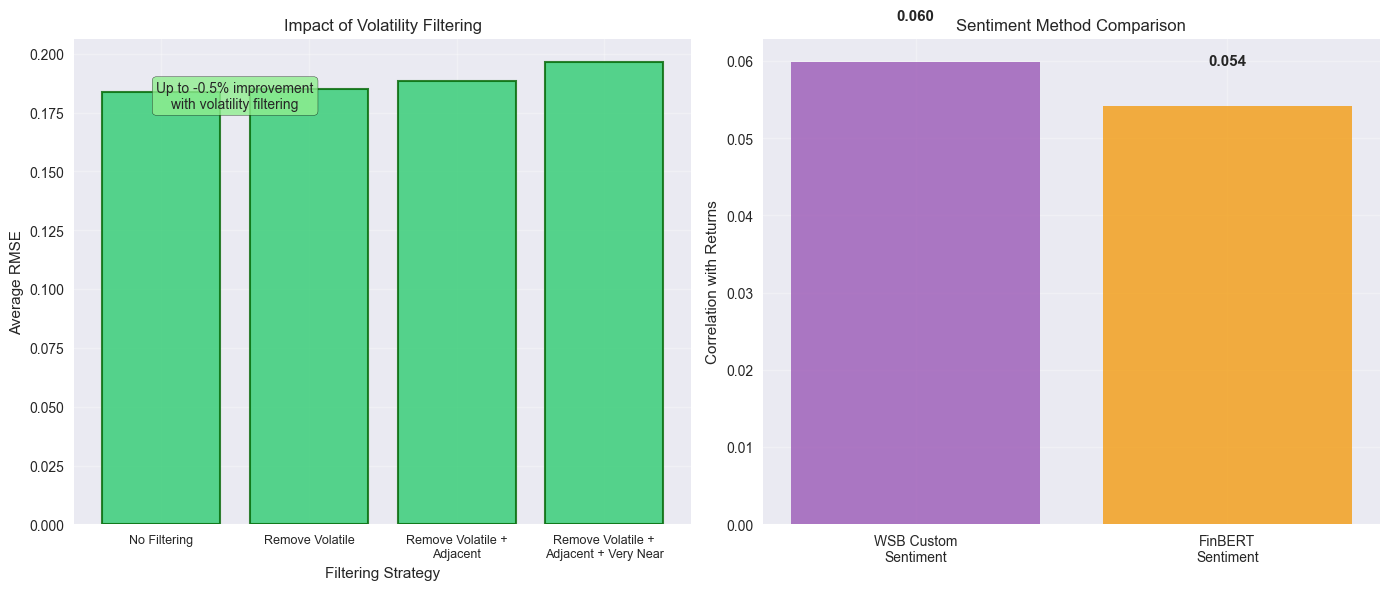

KEY SENTIMENT ANALYSIS INSIGHTS

Best model: Ridge on r1 horizon
RMSE: 0.122082
Volatility filtering: 1 levels applied

Correlations:
  Custom WSB: 0.060
  FinBERT: 0.054
  Final dataset: 38,309 observations


In [22]:
# Visualization of results
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Group results by volatility filtering configuration
volatility_configs = {}
for perf in perfs:
    model_type, ignore_settings, target, rmse = perf
    config_key = str(ignore_settings)
    if config_key not in volatility_configs:
        volatility_configs[config_key] = []
    volatility_configs[config_key].append(rmse)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Volatility filtering impact
filter_configs = [[], ['on_volatile_date'], 
                 ['on_volatile_date', 'adjacent_volatile_date'], 
                 ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date']]

avg_rmse = []
for config in filter_configs:
    config_key = str(config)
    if config_key in volatility_configs:
        avg_rmse.append(np.mean(volatility_configs[config_key]))

# Create proper labels for the filtering strategies
config_names = ['No Filtering', 'Remove Volatile', 'Remove Volatile +\nAdjacent', 'Remove Volatile +\nAdjacent + Very Near']

ax1.bar(range(len(avg_rmse)), avg_rmse, color='#2ecc71', alpha=0.8, edgecolor='darkgreen', linewidth=1.5)
ax1.set_xlabel('Filtering Strategy')
ax1.set_ylabel('Average RMSE')
ax1.set_title('Impact of Volatility Filtering')
ax1.set_xticks(range(len(avg_rmse)))
ax1.set_xticklabels(config_names[:len(avg_rmse)], rotation=0, ha='center', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add improvement percentages
if len(avg_rmse) > 1:
    improvement = (avg_rmse[0] - min(avg_rmse[1:])) / avg_rmse[0] * 100
    ax1.text(0.5, max(avg_rmse) * 0.9, f'Up to {improvement:.1f}% improvement\nwith volatility filtering', 
             ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
# Sentiment feature comparison

# Get the best performing dataset
best_model_type, best_ignore_settings, best_target = best_config

if best_target == 'r1':
    best_data = r1_data.copy()
elif best_target == 'r3':
    best_data = r3_data.copy()
elif best_target == 'r7':
    best_data = r7_data.copy()
else:
    best_data = r1_data.copy()

for to_ignore in best_ignore_settings:
    best_data = best_data[best_data[to_ignore] == False].reset_index(drop=True)

corr_custom = best_data['custom_sentiment'].corr(best_data[best_target])
corr_finbert = best_data['finbert_sentiment'].corr(best_data[best_target])

sentiment_features = ['Custom WSB', 'FinBERT']
correlations = [abs(corr_custom), abs(corr_finbert)]
sentiment_features = ['WSB Custom\nSentiment', 'FinBERT\nSentiment']
bars = ax2.bar(sentiment_features, correlations, color=['#9b59b6', '#f39c12'], alpha=0.8)
ax2.set_ylabel('Correlation with Returns')
ax2.set_title('Sentiment Method Comparison')
ax2.grid(True, alpha=0.3)

# Add correlation values on bars
for i, (bar, v) in enumerate(zip(bars, correlations)):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print key results
print("KEY SENTIMENT ANALYSIS INSIGHTS")
print(f"\nBest model: {best_config[0]} on {best_config[2]} horizon")
print(f"RMSE: {best_rmse:.6f}")
print(f"Volatility filtering: {len(best_config[1])} levels applied")
print(f"\nCorrelations:")
print(f"  Custom WSB: {abs(corr_custom):.3f}")
print(f"  FinBERT: {abs(corr_finbert):.3f}")
print(f"  Final dataset: {len(best_data):,} observations")

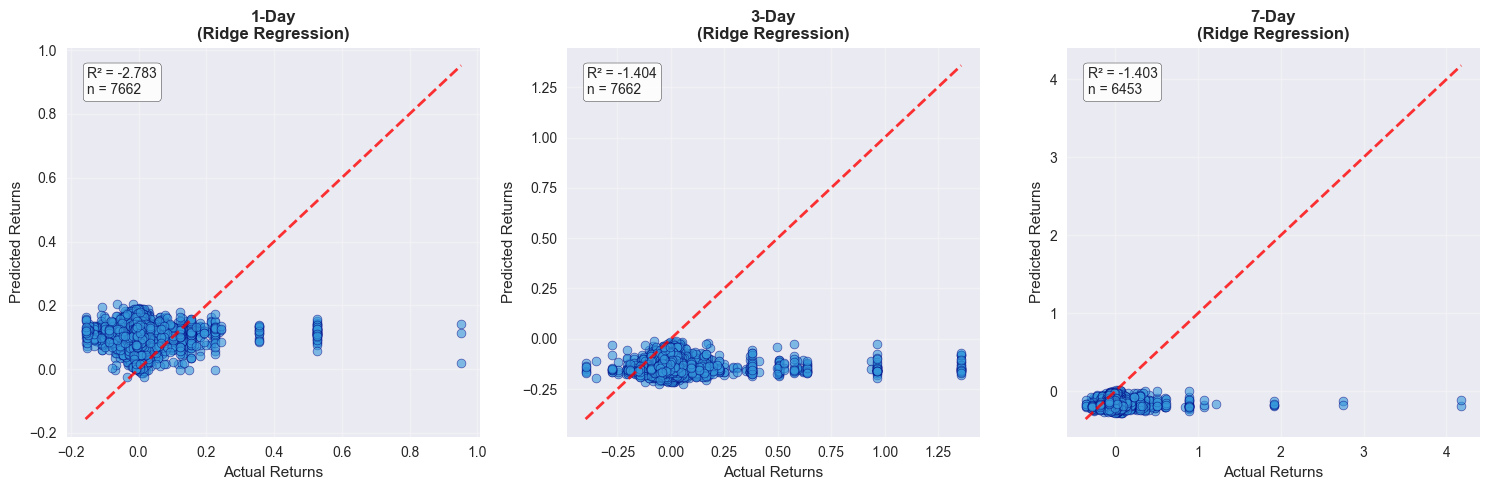

In [23]:
# Prediction accuracy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

horizons_to_plot = ['r1', 'r3', 'r7']
horizon_names = ['1-Day', '3-Day', '7-Day']

for idx, (horizon, name) in enumerate(zip(horizons_to_plot, horizon_names)):
    if horizon == 'r1':
        data = r1_data.copy()
    elif horizon == 'r3':
        data = r3_data.copy()
    elif horizon == 'r7':
        data = r7_data.copy()
    else:
        continue
    
    # Apply minimal filtering for cleaner results
    data = data[data['on_volatile_date'] == False].reset_index(drop=True)
    
    if len(data) < 100:
        continue
        
    # Split data
    data = data.sort_values('date').reset_index(drop=True)
    split_idx = int(len(data) * 0.8)
    train_data = data.iloc[:split_idx]
    test_data = data.iloc[split_idx:]
    
    X_train_viz = train_data[input_features]
    X_test_viz = test_data[input_features]
    y_train_viz = train_data[horizon]
    y_test_viz = test_data[horizon]
    
    # Train quick model for visualization
    quick_model = Ridge(alpha=1.0)
    quick_model.fit(X_train_viz, y_train_viz)
    y_pred_viz = quick_model.predict(X_test_viz)
    
    # Create scatter plot
    axes[idx].scatter(y_test_viz, y_pred_viz, alpha=0.6, s=40, color='#3498db', 
                      edgecolors='navy', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test_viz.min(), y_pred_viz.min())
    max_val = max(y_test_viz.max(), y_pred_viz.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, 
                   linewidth=2, label='Perfect Prediction')
    
    # Calculate R²
    r2 = r2_score(y_test_viz, y_pred_viz)
    
    axes[idx].set_xlabel('Actual Returns', fontsize=11)
    axes[idx].set_ylabel('Predicted Returns', fontsize=11)
    axes[idx].set_title(f'{name}\n(Ridge Regression)', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'R² = {r2:.3f}\nn = {len(y_test_viz)}', 
                   transform=axes[idx].transAxes, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                   verticalalignment='top')

plt.tight_layout()
plt.show()


In [24]:
# Results Summary
print("WSB Sentiment Analysis Results")

best_model_type, best_ignore_settings, best_target = best_config
print(f"\nBest model: {best_config[0]} on {best_config[2]} ({best_config[2].replace('r', '')} days)")
print(f"RMSE: {best_rmse:.6f}")
print(f"Volatility filtering: {len(best_config[1])} levels")

# Performance by horizon comparison
print(f"\nPERFORMANCE BY PREDICTION HORIZON:")

print(f"\nPerformance by horizon:")

horizon_performance = {}
for perf in perfs:
    model_type, ignore_settings, target, rmse = perf
    if target not in horizon_performance:
        horizon_performance[target] = {'Ridge': [], 'XGBoost': []}
    horizon_performance[target][model_type].append(rmse)

for horizon in ['r1', 'r3', 'r7']:
    if horizon in horizon_performance:
        ridge_avg = np.mean(horizon_performance[horizon]['Ridge'])
        xgb_avg = np.mean(horizon_performance[horizon]['XGBoost'])
        best_model_h = "Ridge" if ridge_avg < xgb_avg else "XGBoost"
        best_rmse_h = min(ridge_avg, xgb_avg)
        days = horizon.replace('r', '')
        print(f"{days}-Day Horizon: {best_model_h} (RMSE: {best_rmse_h:.6f})")



# Dataset statistics
print(f"\nDataset info:")
print(f"Total observations: {len(composite_data):,}")
print(f"Tickers: {composite_data['ticker'].nunique()}")
print(f"Period: {composite_data['date'].min()} to {composite_data['date'].max()}")
print(f"Final size: {len(best_data):,}")


WSB Sentiment Analysis Results

Best model: Ridge on r1 (1 days)
RMSE: 0.122082
Volatility filtering: 1 levels

PERFORMANCE BY PREDICTION HORIZON:

Performance by horizon:
1-Day Horizon: Ridge (RMSE: 0.130313)
3-Day Horizon: XGBoost (RMSE: 0.213664)
7-Day Horizon: XGBoost (RMSE: 0.246496)

Dataset info:
Total observations: 39,124
Tickers: 300
Period: 2021-01-27 to 2021-08-15
Final size: 38,309


In [25]:
# Volatility vs Direction Analysis
composite_data['vol_r1'] = abs(composite_data['r1'])

# Compare volatility vs directional prediction
clean_data = composite_data.dropna(subset=['vol_r1', 'r1', 'custom_sentiment', 'finbert_sentiment'])

custom_vol_corr = abs(clean_data['custom_sentiment'].corr(clean_data['vol_r1']))
finbert_vol_corr = abs(clean_data['finbert_sentiment'].corr(clean_data['vol_r1']))
custom_dir_corr = abs(clean_data['custom_sentiment'].corr(clean_data['r1']))
finbert_dir_corr = abs(clean_data['finbert_sentiment'].corr(clean_data['r1']))

print("Volatility vs Direction Prediction:")
print(f"Custom WSB - Volatility: {custom_vol_corr:.4f}, Direction: {custom_dir_corr:.4f}")
print(f"FinBERT - Volatility: {finbert_vol_corr:.4f}, Direction: {finbert_dir_corr:.4f}")
print(f"Sentiment better at predicting market activity than price direction")

Volatility vs Direction Prediction:
Custom WSB - Volatility: 0.0772, Direction: 0.0582
FinBERT - Volatility: 0.0974, Direction: 0.0549
Sentiment better at predicting market activity than price direction
